# Coupled finite-element equilibrium and remodeling

This notebook closes the first staggered mechanics–remodeling loop:

\[
\text{structure at }t_n
\rightarrow
\text{finite-element equilibrium}
\rightarrow
\text{mechanical stimulus}
\rightarrow
\text{updated structure at }t_{n+1}
\rightarrow
\text{new equilibrium}.
\]

> **Data status.** No measured polarimetric tissue maps are available for this
> project yet. The notebook therefore uses a deterministic synthetic benchmark
> with known latent structure, measurement noise, and a low-signal defect.
> Synthetic results verify the computational workflow; they are not experimental
> validation and must not be interpreted as biological evidence.

## 1. Reproducible environment

In [1]:
from __future__ import annotations

import sys
from dataclasses import asdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection, PolyCollection


def find_repository_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists() and (candidate / "src").exists():
            return candidate
    raise RuntimeError("Could not locate the repository root.")


REPOSITORY_ROOT = find_repository_root(Path.cwd().resolve())
SOURCE_DIRECTORY = REPOSITORY_ROOT / "src"
if str(SOURCE_DIRECTORY) not in sys.path:
    sys.path.insert(0, str(SOURCE_DIRECTORY))

from anisotropic_remodeling import (
    EquilibriumRemodelingConfig,
    MaterialParameters,
    RemodelingParameters,
    element_centroids,
    polarimetry_to_structure,
    rectangular_quad_mesh,
    run_equilibrium_remodeling,
    sample_nematic_image_to_elements,
    synthetic_polarimetry_benchmark,
)

np.set_printoptions(precision=6, suppress=True)
print(f"Repository root: {REPOSITORY_ROOT}")
print(f"NumPy version: {np.__version__}")

Repository root: D:\Anisotropic-Soft-Tissue-Remodeling
NumPy version: 1.24.3


## 2. Staggered formulation

At remodeling time \(t_n\), the element fields \(\mathbf a_0^e(t_n)\) and
\(\beta^e(t_n)\) are fixed while the finite-element equilibrium problem is
solved:

\[
\int_{\Omega_0}\mathbf P:\nabla_X\delta\mathbf u\,dV=0,
\qquad
\mathbf P=\frac{\partial\psi}{\partial\mathbf F}.
\]

The equilibrium deformation gradient defines

\[
S^e=\left|\ln\lambda_{\max}^e-\ln\lambda_{\min}^e\right|
\]

and the target direction \(\mathbf n_{\max}^e\). The structure is then updated
with the exact relaxation formulas already verified in earlier notebooks. The
previous equilibrium displacement is reused as a warm start for the next solve.

The applied boundary displacement is held fixed during remodeling. Therefore,
any change in boundary reaction is caused by structural adaptation and the
resulting redistribution of the equilibrium field.

## 3. Synthetic polarimetry benchmark

In [2]:
benchmark = synthetic_polarimetry_benchmark(
    width=2.0,
    height=1.0,
    number_of_points_x=81,
    number_of_points_y=41,
    random_seed=7,
)

reconstructed = polarimetry_to_structure(
    benchmark.observed_azimuth_rad,
    benchmark.observed_retardance,
    benchmark.calibration,
    minimum_valid_retardance=0.16,
    external_valid_mask=benchmark.external_valid_mask,
    coherence_window=7,
)

print(f"Map shape: {benchmark.x.shape}")
print(f"Valid reconstructed pixels: {np.count_nonzero(reconstructed.valid_mask)}")
print(f"Excluded pixels: {reconstructed.valid_mask.size - np.count_nonzero(reconstructed.valid_mask)}")
print("Calibration:")
for name, value in asdict(benchmark.calibration).items():
    print(f"  {name}: {value}")

Map shape: (41, 81)
Valid reconstructed pixels: 3276
Excluded pixels: 45
Calibration:
  lower_retardance: 0.2
  upper_retardance: 0.8
  beta_min: 0.1
  beta_max: 0.7
  exponent: 1.0


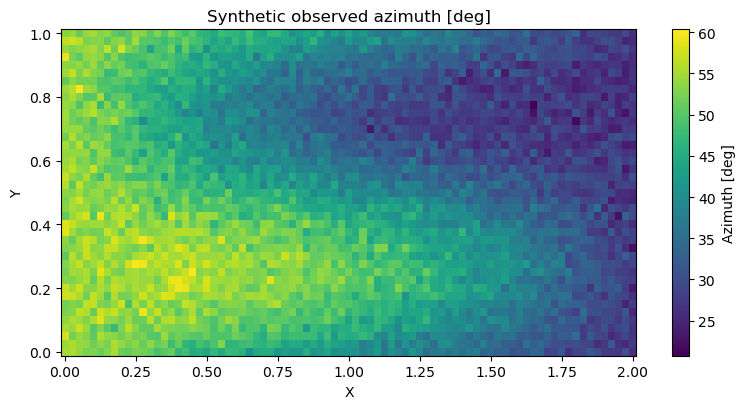

In [3]:
figure, axis = plt.subplots(figsize=(8, 4.2))
image = axis.pcolormesh(
    benchmark.x,
    benchmark.y,
    np.rad2deg(np.mod(benchmark.observed_azimuth_rad, np.pi)),
    shading="auto",
)
axis.set(xlabel="X", ylabel="Y", title="Synthetic observed azimuth [deg]")
figure.colorbar(image, ax=axis, label="Azimuth [deg]")
figure.tight_layout()
plt.show()

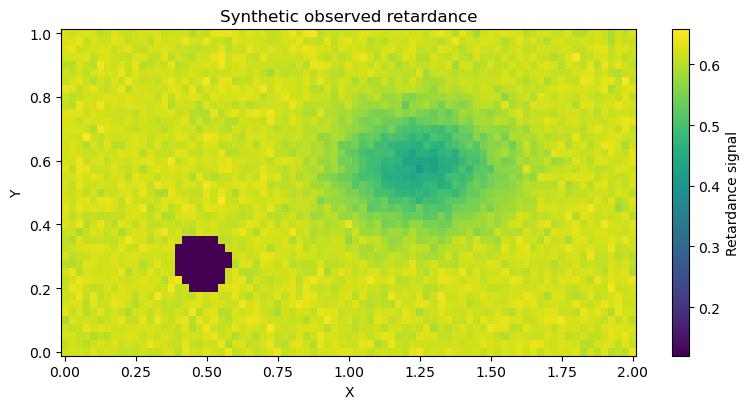

In [4]:
figure, axis = plt.subplots(figsize=(8, 4.2))
image = axis.pcolormesh(
    benchmark.x,
    benchmark.y,
    benchmark.observed_retardance,
    shading="auto",
)
axis.set(xlabel="X", ylabel="Y", title="Synthetic observed retardance")
figure.colorbar(image, ax=axis, label="Retardance signal")
figure.tight_layout()
plt.show()

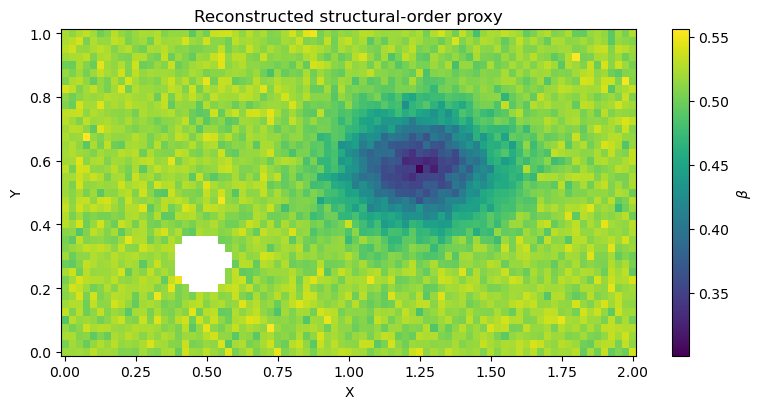

In [5]:
masked_beta = np.where(reconstructed.valid_mask, reconstructed.structural_order, np.nan)
figure, axis = plt.subplots(figsize=(8, 4.2))
image = axis.pcolormesh(benchmark.x, benchmark.y, masked_beta, shading="auto")
axis.set(xlabel="X", ylabel="Y", title="Reconstructed structural-order proxy")
figure.colorbar(image, ax=axis, label=r"$\beta$")
figure.tight_layout()
plt.show()

## 4. Transfer to a finite-element mesh

The benchmark map is sampled at element centroids. Fiber orientation is averaged
in doubled-angle space, preserving the nematic equivalence
\(\mathbf a_0\equiv-\mathbf a_0\).

In [6]:
mesh = rectangular_quad_mesh(5, 3, width=2.0, height=1.0)
centroids = element_centroids(mesh)
element_fiber, element_beta = sample_nematic_image_to_elements(
    centroids,
    benchmark.x,
    benchmark.y,
    reconstructed.fiber_direction,
    reconstructed.structural_order,
    reconstructed.valid_mask,
    neighbors=20,
)

initial_angles_deg = np.rad2deg(
    np.mod(np.arctan2(element_fiber[:, 1], element_fiber[:, 0]), np.pi)
)
print(f"Nodes: {mesh.number_of_nodes}")
print(f"Elements: {mesh.number_of_elements}")
print(f"Initial angle range: {initial_angles_deg.min():.3f}–{initial_angles_deg.max():.3f} deg")
print(f"Initial beta range: {element_beta.min():.6f}–{element_beta.max():.6f}")
print(f"Initial mean beta: {element_beta.mean():.6f}")

Nodes: 24
Elements: 15
Initial angle range: 24.944–55.555 deg
Initial beta range: 0.408142–0.530394
Initial mean beta: 0.503896


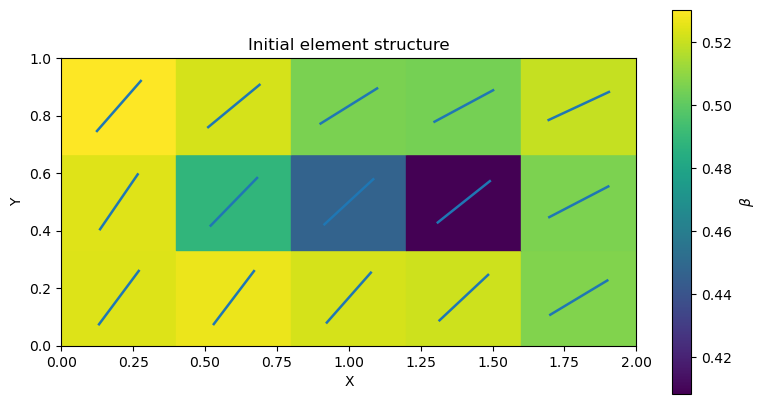

In [7]:
def plot_element_structure(mesh, fiber, beta, title):
    polygons = mesh.nodes[mesh.elements]
    collection = PolyCollection(polygons, array=np.asarray(beta), edgecolors="face")
    figure, axis = plt.subplots(figsize=(8, 4.2))
    axis.add_collection(collection)
    centers = np.mean(polygons, axis=1)
    half_length = 0.12
    segments = np.stack(
        (centers - half_length * fiber, centers + half_length * fiber),
        axis=1,
    )
    axis.add_collection(LineCollection(segments, linewidths=1.8))
    axis.set(
        xlabel="X",
        ylabel="Y",
        title=title,
        xlim=(0.0, mesh.width),
        ylim=(0.0, mesh.height),
        aspect="equal",
    )
    figure.colorbar(collection, ax=axis, label=r"$\beta$")
    figure.tight_layout()
    plt.show()


plot_element_structure(mesh, element_fiber, element_beta, "Initial element structure")

## 5. Mechanical and kinetic parameters

In [8]:
material = MaterialParameters(mu=2.0, kappa=60.0, k1=2.0, k2=3.0)
remodeling = RemodelingParameters(
    orientation_rate=0.7,
    order_rate=0.5,
    beta_min=0.1,
    beta_max=1.0,
    half_saturation=0.1,
    hill_exponent=2.0,
)
config = EquilibriumRemodelingConfig(
    total_time=4.0,
    dt=0.5,
    axial_extension=0.06,
    initial_load_steps=3,
    subsequent_load_steps=1,
    gradient_tolerance=3.0e-7,
    maximum_iterations=400,
)

for heading, values in (
    ("Material", asdict(material)),
    ("Remodeling", asdict(remodeling)),
    ("Coupling", asdict(config)),
):
    print(heading)
    for name, value in values.items():
        print(f"  {name}: {value}")

Material
  mu: 2.0
  kappa: 60.0
  k1: 2.0
  k2: 3.0
Remodeling
  orientation_rate: 0.7
  order_rate: 0.5
  beta_min: 0.1
  beta_max: 1.0
  half_saturation: 0.1
  hill_exponent: 2.0
Coupling
  total_time: 4.0
  dt: 0.5
  axial_extension: 0.06
  initial_load_steps: 3
  subsequent_load_steps: 1
  gradient_tolerance: 3e-07
  maximum_iterations: 400
  minimum_jacobian: 0.2


## 6. Coupled equilibrium-remodeling calculation

In [9]:
result = run_equilibrium_remodeling(
    mesh,
    element_fiber,
    element_beta,
    material,
    remodeling,
    config,
)

reaction_change_percent = 100.0 * (
    result.right_reaction[-1, 0] / result.right_reaction[0, 0] - 1.0
)

print(f"Time points: {result.time.size}")
print(f"Initial mean beta: {result.mean_structural_order[0]:.6f}")
print(f"Final mean beta: {result.mean_structural_order[-1]:.6f}")
print(f"Initial mean target alignment: {result.mean_target_alignment[0]:.6f}")
print(f"Final mean target alignment: {result.mean_target_alignment[-1]:.6f}")
print(f"Initial right reaction: {result.right_reaction[0, 0]:.6f}")
print(f"Final right reaction: {result.right_reaction[-1, 0]:.6f}")
print(f"Reaction change: {reaction_change_percent:.3f}%")

Time points: 9
Initial mean beta: 0.503896
Final mean beta: 0.596892
Initial mean target alignment: 0.532722
Final mean target alignment: 0.983421
Initial right reaction: 0.454476
Final right reaction: 0.743294
Reaction change: 63.549%


### 6.1 Structural-order evolution

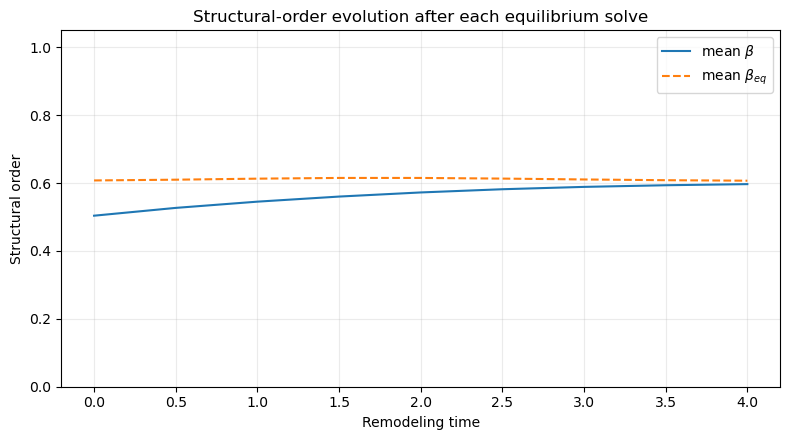

In [10]:
figure, axis = plt.subplots(figsize=(8, 4.5))
axis.plot(result.time, result.mean_structural_order, label=r"mean $\beta$")
axis.plot(result.time, result.mean_equilibrium_order, linestyle="--", label=r"mean $\beta_{eq}$")
axis.set(
    xlabel="Remodeling time",
    ylabel="Structural order",
    title="Structural-order evolution after each equilibrium solve",
    ylim=(0.0, 1.05),
)
axis.grid(True, alpha=0.25)
axis.legend()
figure.tight_layout()
plt.show()

### 6.2 Fiber alignment with the local mechanical target

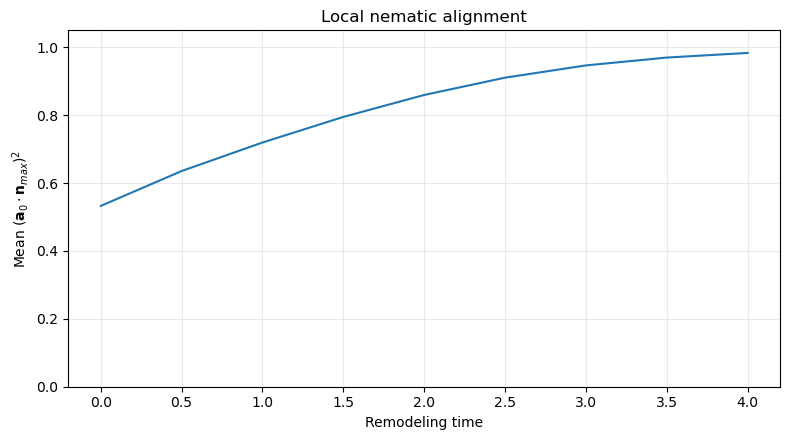

In [11]:
figure, axis = plt.subplots(figsize=(8, 4.5))
axis.plot(result.time, result.mean_target_alignment)
axis.set(
    xlabel="Remodeling time",
    ylabel=r"Mean $(\mathbf{a}_0\cdot\mathbf{n}_{max})^2$",
    title="Local nematic alignment",
    ylim=(0.0, 1.05),
)
axis.grid(True, alpha=0.25)
figure.tight_layout()
plt.show()

### 6.3 Boundary reaction at fixed displacement

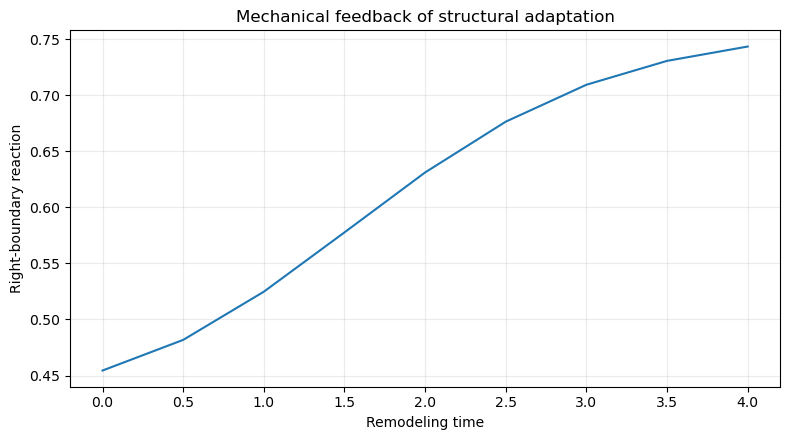

In [12]:
figure, axis = plt.subplots(figsize=(8, 4.5))
axis.plot(result.time, result.right_reaction[:, 0])
axis.set(
    xlabel="Remodeling time",
    ylabel="Right-boundary reaction",
    title="Mechanical feedback of structural adaptation",
)
axis.grid(True, alpha=0.25)
figure.tight_layout()
plt.show()

### 6.4 Mean axial stress

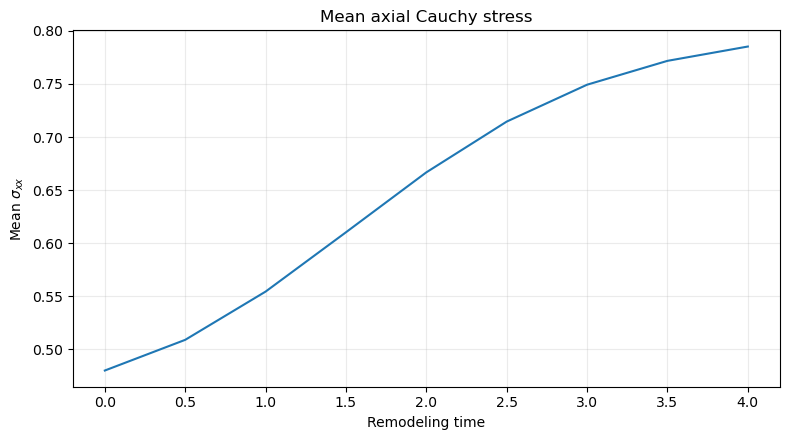

In [13]:
figure, axis = plt.subplots(figsize=(8, 4.5))
axis.plot(result.time, result.mean_cauchy_stress_xx)
axis.set(
    xlabel="Remodeling time",
    ylabel=r"Mean $\sigma_{xx}$",
    title="Mean axial Cauchy stress",
)
axis.grid(True, alpha=0.25)
figure.tight_layout()
plt.show()

### 6.5 Initial and final structural fields

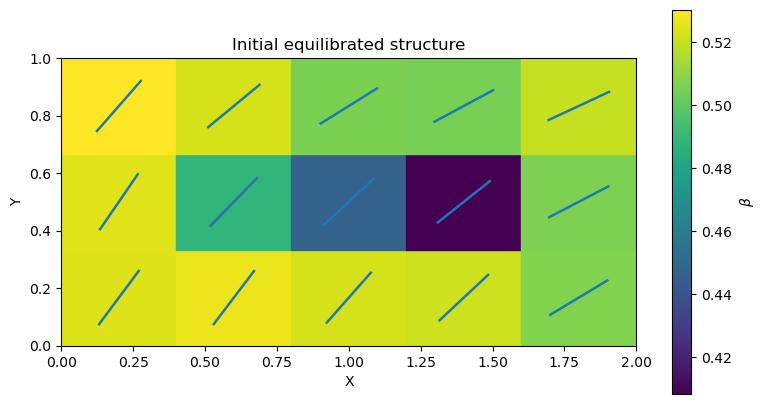

In [14]:
plot_element_structure(
    mesh,
    result.fiber_direction[0],
    result.structural_order[0],
    "Initial equilibrated structure",
)

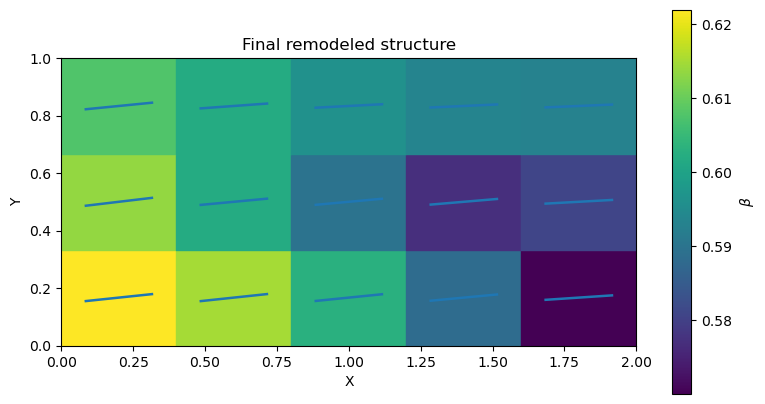

In [15]:
plot_element_structure(
    mesh,
    result.fiber_direction[-1],
    result.structural_order[-1],
    "Final remodeled structure",
)

## 7. Mechanical and numerical checks

For every remodeling time point, the following conditions are checked:

- nonlinear equilibrium converged;
- all element Jacobians remain positive;
- the free-degree-of-freedom residual is small;
- left and right horizontal reactions balance;
- fiber vectors remain normalized;
- \(\beta\in[0,1]\);
- Cauchy stress remains symmetric.

In [16]:
reaction_balance = np.max(
    np.abs(result.left_reaction[:, 0] + result.right_reaction[:, 0])
)
stress_asymmetry = np.max(
    np.abs(
        result.element_cauchy_stress
        - np.swapaxes(result.element_cauchy_stress, -1, -2)
    )
)
fiber_norm_error = np.max(
    np.abs(np.linalg.norm(result.fiber_direction, axis=-1) - 1.0)
)

checks = {
    "all equilibrium solves converged": bool(np.all(result.converged)),
    "positive element Jacobians": bool(np.min(result.element_jacobian) > config.minimum_jacobian),
    "small free-DOF residual": bool(np.max(result.free_dof_residual_norm) < 5.0e-6),
    "balanced horizontal reactions": bool(reaction_balance < 5.0e-5),
    "unit fiber directions": bool(fiber_norm_error < 1.0e-12),
    "bounded structural order": bool(
        np.all((result.structural_order >= 0.0) & (result.structural_order <= 1.0))
    ),
    "symmetric Cauchy stress": bool(stress_asymmetry < 1.0e-10),
}

for name, passed in checks.items():
    print(f"{'PASS' if passed else 'FAIL'} — {name}")
print(f"Maximum residual: {np.max(result.free_dof_residual_norm):.3e}")
print(f"Minimum J: {np.min(result.element_jacobian):.6f}")
print(f"Maximum reaction imbalance: {reaction_balance:.3e}")
print(f"Maximum stress asymmetry: {stress_asymmetry:.3e}")
assert all(checks.values())

PASS — all equilibrium solves converged
PASS — positive element Jacobians
PASS — small free-DOF residual
PASS — balanced horizontal reactions
PASS — unit fiber directions
PASS — bounded structural order
PASS — symmetric Cauchy stress
Maximum residual: 2.600e-07
Minimum J: 1.002297
Maximum reaction imbalance: 8.604e-08
Maximum stress asymmetry: 1.952e-17


### 7.1 Nonlinear-solver work

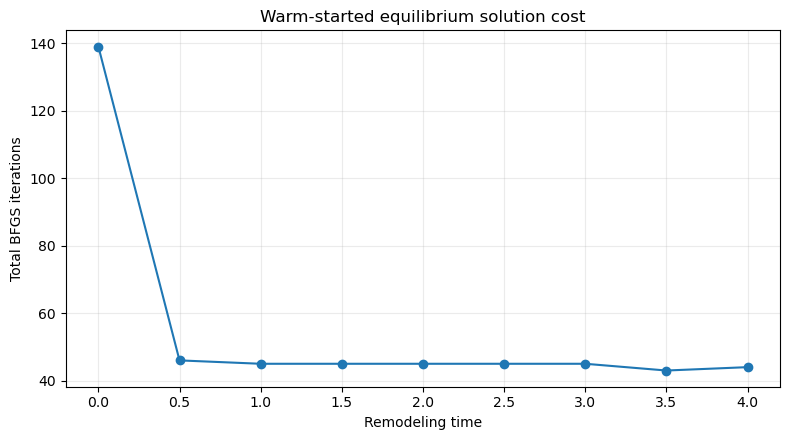

In [17]:
figure, axis = plt.subplots(figsize=(8, 4.5))
axis.plot(result.time, result.iterations, marker="o")
axis.set(
    xlabel="Remodeling time",
    ylabel="Total BFGS iterations",
    title="Warm-started equilibrium solution cost",
)
axis.grid(True, alpha=0.25)
figure.tight_layout()
plt.show()

## 8. Export reproducible histories

In [18]:
data_directory = REPOSITORY_ROOT / "results" / "data"
figure_directory = REPOSITORY_ROOT / "results" / "figures"
data_directory.mkdir(parents=True, exist_ok=True)
figure_directory.mkdir(parents=True, exist_ok=True)

npz_path = data_directory / "equilibrium_remodeling_coupling_fields.npz"
np.savez_compressed(
    npz_path,
    nodes=mesh.nodes,
    elements=mesh.elements,
    time=result.time,
    displacement=result.displacement,
    fiber_direction=result.fiber_direction,
    fiber_angle_deg=result.fiber_angle_deg,
    structural_order=result.structural_order,
    equilibrium_order=result.equilibrium_order,
    stimulus=result.stimulus,
    target_direction=result.target_direction,
    deformation_gradient=result.element_deformation_gradient,
    jacobian=result.element_jacobian,
    strain_energy=result.element_strain_energy,
    cauchy_stress=result.element_cauchy_stress,
    left_reaction=result.left_reaction,
    right_reaction=result.right_reaction,
)

csv_path = data_directory / "equilibrium_remodeling_coupling_history.csv"
history = np.column_stack(
    (
        result.time,
        result.mean_structural_order,
        result.mean_equilibrium_order,
        result.mean_stimulus,
        result.mean_strain_energy,
        result.mean_cauchy_stress_xx,
        result.mean_target_alignment,
        result.orientation_coherence,
        result.right_reaction[:, 0],
        result.free_dof_residual_norm,
        result.iterations,
    )
)
np.savetxt(
    csv_path,
    history,
    delimiter=",",
    comments="",
    header=(
        "time,mean_beta,mean_beta_equilibrium,mean_stimulus,mean_strain_energy,"
        "mean_sigma_xx,mean_target_alignment,orientation_coherence,"
        "right_reaction_x,residual_inf,total_iterations"
    ),
)
print(npz_path.relative_to(REPOSITORY_ROOT))
print(csv_path.relative_to(REPOSITORY_ROOT))

results\data\equilibrium_remodeling_coupling_fields.npz
results\data\equilibrium_remodeling_coupling_history.csv


## 9. Interpretation and limitations

For this synthetic benchmark, the initially oblique fibers rotate toward their
local maximum-principal-stretch directions. The mean structural-order parameter
relaxes toward the mechanically defined equilibrium level. Because the sample is
held at fixed displacement, better fiber alignment changes the effective axial
stiffness and therefore changes the boundary reaction.

This is the first genuinely closed feedback loop in the repository, but it is
still a methodological benchmark. The result demonstrates internal consistency
of the implemented equations; it does not validate them against tissue data.